# 01 — Residential PM₂.₅ exposure in Helsinki

**Purpose.** Establish the place-based baseline: sample the FMI-ENFUSER PM₂.₅ surface at populated CAFEIN grid cells.

This is the first layer of the proof of concept. It describes ambient PM₂.₅ at populated locations and does **not** yet account for daily mobility or exposure while travelling.


## 1. Environment and CAFEIN sample-data paths


In [15]:
#pip install -U cafein.sampledata rasterio geopandas matplotlib

In [16]:
import cafein.sampledata.helsinki as helsinki
import rasterio
import geopandas as gpd

print("Air quality:", helsinki.air_quality)
print("Population grid:", helsinki.population_grid)
print("GTFS:", helsinki.gtfs)

Air quality: /users/modjrian/.cache/x86_64/cafein-sampledata/helsinki/helsinki-2026.08.4/e9e1a0a02590aae38aaaef126cbfc39c38e788e7e9f9390f9234c9f3461b6b4e/helsinki_air_quality.tif
Population grid: /users/modjrian/.cache/x86_64/cafein-sampledata/helsinki/helsinki-2026.08.4/4ab1248addc19cdb0bcde6cd3cf1741d0da12475b800ff8870eb270afc80bb8c/hsy_population_grid_250m.gpkg
GTFS: /users/modjrian/.cache/x86_64/cafein-sampledata/helsinki/helsinki-2026.08.4/c62722e860626a541747733b68be803c0e7b4bb45fde9b0358cb8f2b4099d0e7/hsl_gtfs.zip


## 2. Inspect the FMI-ENFUSER air-quality raster


In [17]:
aq_path = helsinki.air_quality

with rasterio.open(aq_path) as src:
    print("CRS:", src.crs)
    print("Bands:", src.count)
    print("Descriptions:")
    for i, desc in enumerate(src.descriptions, start=1):
        print(i, desc)

    print("Bounds:", src.bounds)
    print("Resolution:", src.res)

CRS: EPSG:4326
Bands: 8
Descriptions:
1 AQIndex [1]
2 NO2Concentration [ug/m3]
3 O3Concentration [ug/m3]
4 PM10Concentration [ug/m3]
5 PM25Concentration [ug/m3]
6 LungDepositedSurfaceArea [um2/cm3]
7 BlackCarbonConcentration [ug/m3]
8 ParticleNumberConcentration [1/cm3]
Bounds: BoundingBox(left=24.579882090898522, bottom=60.36805850867299, right=25.199918324140544, top=60.132040673455926)
Resolution: (0.00023566561506728256, 0.00011695631081122955)


## 3. Visualize the PM₂.₅ surface

Band 5 is used for PM₂.₅ in the CAFEIN Helsinki sample raster.


PM2.5 min: 1.899999976158142
PM2.5 max: 5.300000190734863
PM2.5 median: 2.5


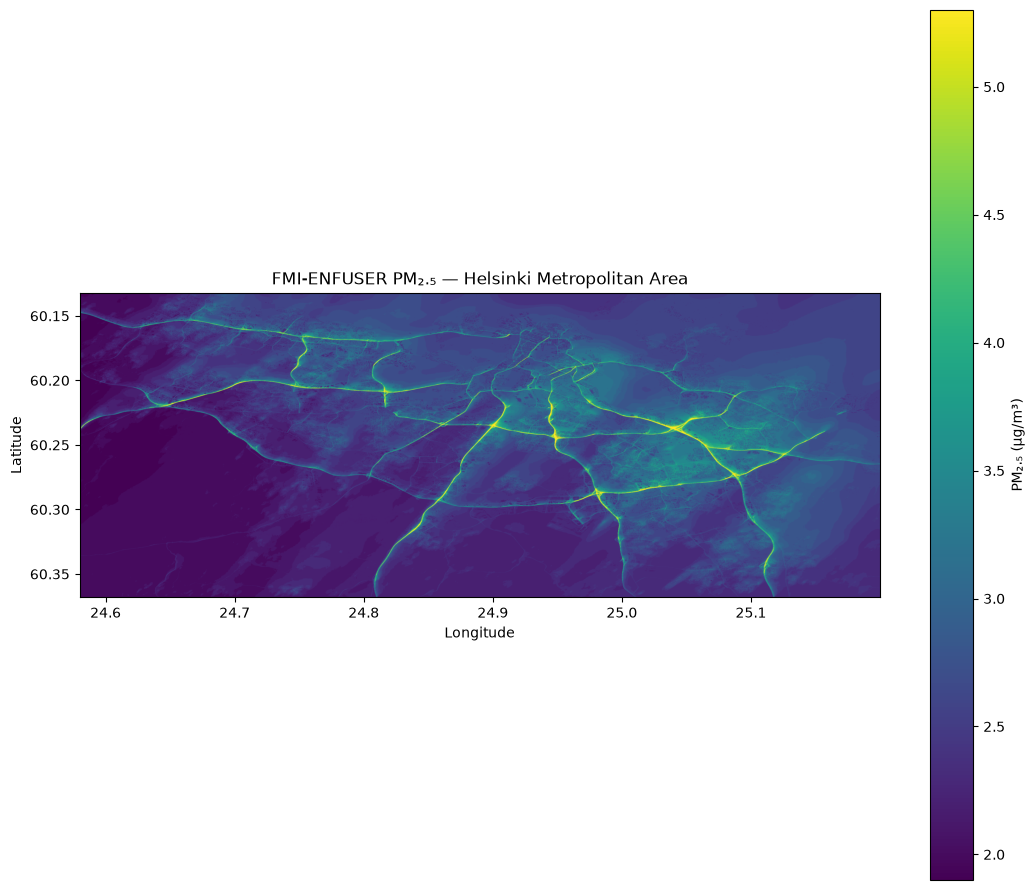

In [18]:
import matplotlib.pyplot as plt
import numpy as np

with rasterio.open(aq_path) as src:
    pm25 = src.read(5).astype(float)

    if src.nodata is not None:
        pm25[pm25 == src.nodata] = np.nan

    bounds = src.bounds

extent = [
    bounds.left,
    bounds.right,
    bounds.bottom,
    bounds.top
]

print("PM2.5 min:", np.nanmin(pm25))
print("PM2.5 max:", np.nanmax(pm25))
print("PM2.5 median:", np.nanmedian(pm25))

plt.figure(figsize=(11, 9))

img = plt.imshow(
    pm25,
    extent=extent,
    origin="upper"
)

plt.colorbar(
    img,
    label="PM₂.₅ (µg/m³)"
)

plt.title("FMI-ENFUSER PM₂.₅ — Helsinki Metropolitan Area")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

## 4. Load the CAFEIN population grid


In [19]:
import geopandas as gpd
import cafein.sampledata.helsinki as helsinki

pop = gpd.read_file(helsinki.population_grid)

print("CRS:", pop.crs)
print("Rows:", len(pop))
print(pop.columns.tolist())

display(pop.head())

CRS: EPSG:3067
Rows: 5825
['id', 'index', 'asukkaita', 'asvaljyys', 'ika0_9', 'ika10_19', 'ika20_29', 'ika30_39', 'ika40_49', 'ika50_59', 'ika60_69', 'ika70_79', 'ika_yli80', 'paivitys_pvm', 'geometry']


,id,index,asukkaita,asvaljyys,ika0_9,ika10_19,ika20_29,ika30_39,ika40_49,ika50_59,ika60_69,ika70_79,ika_yli80,paivitys_pvm,geometry
0,Vaestotietoruudukko_2025.1,688,6,57.17,99,99,99,99,99,99,99,99,99,2026-08-05,"POLYGON ((362054.365 6689582.191, 362061.946 6..."
1,Vaestotietoruudukko_2025.2,703,6,42.83,99,99,99,99,99,99,99,99,99,2026-08-05,"POLYGON ((361940.674 6685834.568, 361948.252 6..."
2,Vaestotietoruudukko_2025.3,710,6,59.33,99,99,99,99,99,99,99,99,99,2026-08-05,"POLYGON ((361887.631 6684085.685, 361895.208 6..."
3,Vaestotietoruudukko_2025.4,711,6,99.33,99,99,99,99,99,99,99,99,99,2026-08-05,"POLYGON ((361880.054 6683835.845, 361887.631 6..."
4,Vaestotietoruudukko_2025.5,715,8,56.50,99,99,99,99,99,99,99,99,99,2026-08-05,"POLYGON ((361849.748 6682836.473, 361857.325 6..."


## 5. Sample PM₂.₅ at populated grid-cell centroids


In [20]:
import rasterio
import numpy as np

# use centroids of population cells
pop_pts = pop.copy()
pop_pts["geometry"] = pop_pts.geometry.centroid

with rasterio.open(helsinki.air_quality) as src:
    raster_crs = src.crs

# match CRS
pop_pts = pop_pts.to_crs(raster_crs)

coords = [
    (geom.x, geom.y)
    for geom in pop_pts.geometry
]

with rasterio.open(helsinki.air_quality) as src:
    pm25_values = [
        x[0]
        for x in src.sample(coords, indexes=5)
    ]

pop_pts["pm25"] = pm25_values

pop_pts.loc[
    (pop_pts["pm25"] < 0) |
    (pop_pts["pm25"] > 1000),
    "pm25"
] = np.nan

display(
    pop_pts[["pm25", "geometry"]].head()
)

,pm25,geometry
0,0.0,POINT (24.50461 60.32041)
1,0.0,POINT (24.50512 60.28675)
2,0.0,POINT (24.50535 60.27105)
3,0.0,POINT (24.50539 60.2688)
4,0.0,POINT (24.50552 60.25983)


## 6. Map residential / populated-location PM₂.₅


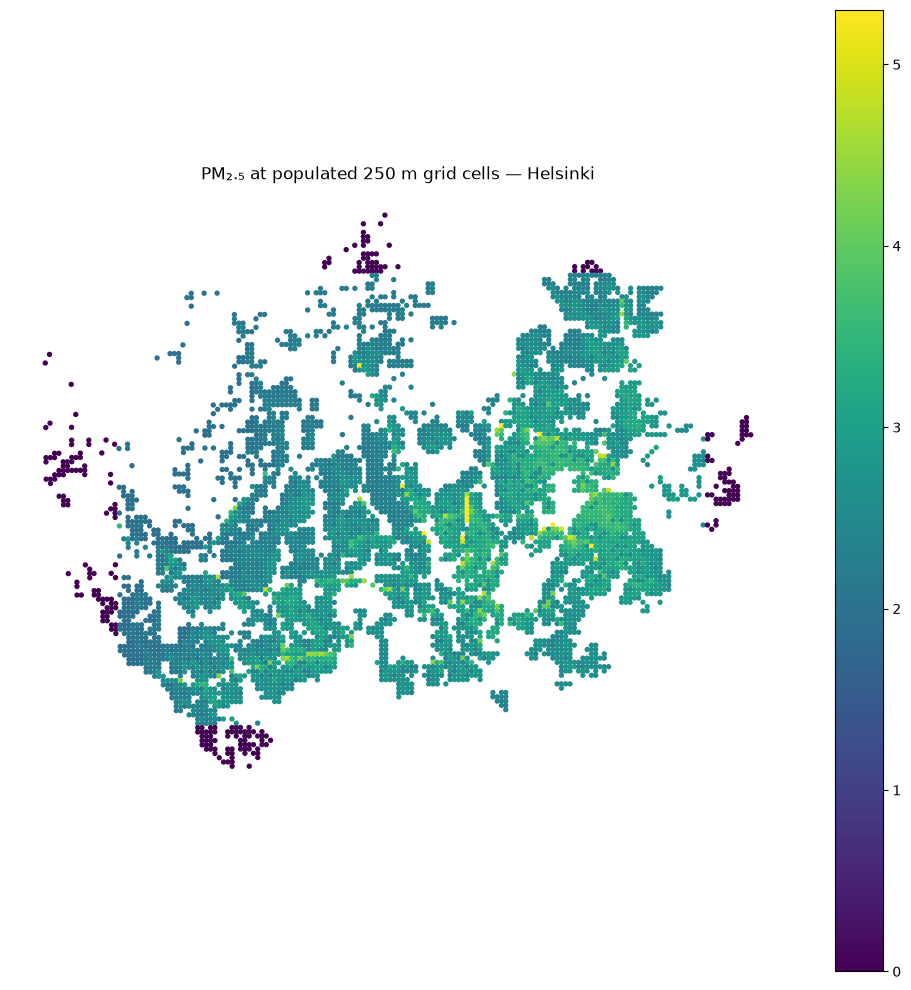

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

pop_pts.plot(
    column="pm25",
    markersize=8,
    legend=True,
    ax=ax
)

ax.set_title(
    "PM₂.₅ at populated 250 m grid cells — Helsinki"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

### Interpretation guardrail

This is a **spatial residential/population exposure proxy**. It does not show where people spend the rest of the day, which destinations they visit, or the concentration they encounter while travelling. Those extensions are handled in Notebooks 02 and 03.
